# The IBIM forward solver, one step at a time

This notebook walks the repo's forward solver along the five stages of the pipeline:

```
phi(x,y)
   |                                        neural_sdf.py
extract tubular region  |phi| <= eps
   |                                        ibim_geometry.py
boundary points + normals + weights
   |                                        ibim_geometry.py
Muller_BIE(boundary, eps_in, eps_out, freq, source)
   |                                        ibim_tmz_system.py / ibim_tmz_forward.py
receiver fields
```

**Method.** Each stage is first written out transparently in a few lines, then
checked against the repo's own function with an assertion. So the notebook is
readable *and* provably the same computation — if the repo changes, a cell fails.

**The seam worth noticing.** Stages 1-3 are `torch` (differentiable: the whole
point of IBIM is that gradients flow back to the SDF parameters). Stages 4-5 are
`numpy`. That boundary is the single most important structural fact in the
codebase, and the notebook keeps it visible rather than papering over it.

**Kernel:** `EMNerf` (Python 3.9).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "gpr_bem").is_dir() and (candidate / "config" / "simulation_config.py").is_file():
            return candidate
    raise RuntimeError("Could not find repo root containing gpr_bem/ and config/simulation_config.py")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
loaded_config = sys.modules.get("config")
if loaded_config is not None and not str(getattr(loaded_config, "__file__", "")).startswith(str(repo_root)):
    del sys.modules["config"]

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.special import jv, hankel1, jvp, h1vp

import config.simulation_config as cfg
from gpr_bem import (
    build_implicit_boundary_band, compress_implicit_boundary_band,
    build_implicit_boundary_operator_family, build_ibim_tmz_frequency_system,
    ibim_incident_trace_on_boundary, solve_ibim_tmz_total_field_batch,
    implicit_single_layer_potential_from_band, implicit_double_layer_potential_from_band,
    Material,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("python  ", sys.version.split()[0])
print("config  ", cfg.__file__)
print("torch   ", torch.__version__)

python   3.9.25
config   /home/drdeng/Neural_SDF_BEM_AD/config/simulation_config.py
torch    2.8.0+cu128


## Setup: the physical problem

Straight from `config/simulation_config.py` — a plastic cylinder buried in sand.
We start at 0.5 GHz rather than the config's 2.5 GHz so the geometry is
comfortably resolved; frequency is swept later.

In [ ]:
RADIUS = cfg.TARGET_RADIUS                 # 0.05 m
CENTER = (cfg.TARGET_CENTER_X, cfg.TARGET_CENTER_Y)
SAND    = Material(epsr=cfg.SAND_EPSR,    sigma=cfg.SAND_SIGMA)      # exterior
PLASTIC = Material(epsr=cfg.PLASTIC_EPSR, sigma=cfg.PLASTIC_SIGMA)   # interior

FREQ  = 0.5e9
OMEGA = 2.0 * np.pi * FREQ
K_EXT = complex(SAND.wavenumber(OMEGA, cfg.EPS0, cfg.MU0))
K_INT = complex(PLASTIC.wavenumber(OMEGA, cfg.EPS0, cfg.MU0))

# A box a few radii wide is all the tubular region needs.
BOUNDS = ((CENTER[0] - 3*RADIUS, CENTER[1] - 3*RADIUS),
          (CENTER[0] + 3*RADIUS, CENTER[1] + 3*RADIUS))

print("radius %.3f m, exterior epsr=%.1f, interior epsr=%.1f" %
      (RADIUS, SAND.epsr, PLASTIC.epsr))
print("f = %.2f GHz   k_ext = %.1f rad/m  (lambda = %.4f m)" %
      (FREQ/1e9, K_EXT.real, 2*np.pi/K_EXT.real))
print("k_int = %.1f rad/m   k*R = %.2f  (cylinder is %.1f wavelengths across)" %
      (K_INT.real, K_EXT.real*RADIUS, 2*RADIUS/(2*np.pi/K_EXT.real)))

radius 0.050 m, exterior epsr=6.0, interior epsr=3.0
f = 0.50 GHz   k_ext = 25.7 rad/m  (lambda = 0.2448 m)
k_int = 18.2 rad/m   k*R = 1.28  (cylinder is 0.4 wavelengths across)


## Step 1 — `phi(x, y)`

The shape is whatever function returns a signed distance. We use the analytic
circle so every downstream quantity has an exact value to check against
(`|grad phi| = 1`, curvature `= 1/R`, perimeter `= 2*pi*R`).

`SirenSDF2D` from `neural_sdf.py` is a drop-in with the identical signature —
`(N,2) -> (N,1)` — so swapping it changes nothing below.

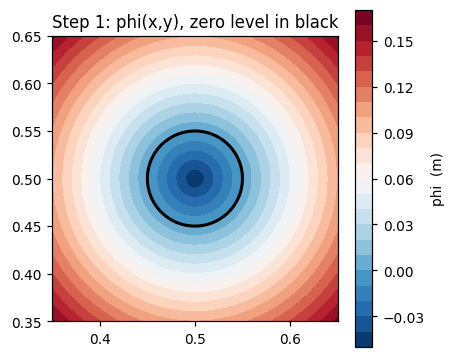

In [3]:
def phi(points: torch.Tensor) -> torch.Tensor:
    '''Signed distance to a circle. (N,2) -> (N,1).'''
    center = torch.tensor(CENTER, dtype=points.dtype, device=points.device)
    return torch.linalg.norm(points - center, dim=1, keepdim=True) - RADIUS

# quick look
g = torch.linspace(BOUNDS[0][0], BOUNDS[1][0], 241, dtype=torch.float64)
GX, GY = torch.meshgrid(g, g, indexing="xy")
PHI = phi(torch.stack((GX.ravel(), GY.ravel()), dim=1)).reshape(GX.shape)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
m = ax.contourf(GX, GY, PHI, levels=24, cmap="RdBu_r")
ax.contour(GX, GY, PHI, levels=[0.0], colors="k", linewidths=2)
plt.colorbar(m, ax=ax, label="phi  (m)")
ax.set_aspect("equal"); ax.set_title("Step 1: phi(x,y), zero level in black")
plt.tight_layout(); plt.show()

## Step 2 — extract the tubular region

Here is where this differs from a contour-tracing pipeline. We never *find* the
curve. We lay down a fixed Cartesian grid, evaluate `phi` and `grad phi`, and keep
the points inside a narrow band `|phi| <= eps`.

**The grid never moves.** When the shape parameters change, the grid stays put —
what changes is which points fall in the band and what weight each one carries.
That is exactly why this is differentiable and marching squares is not: no
discrete "which cells does the contour cross" decision ever happens.

The one knob is the band half-width `eps` (default `2.5 h`): too thin and the
quadrature is noisy, too thick and the smoothed delta smears the geometry.

grid 161x161, h = 0.00188 m, band half-width eps = 0.00469 m
grid points 25921  ->  band points 856  (3.3%)


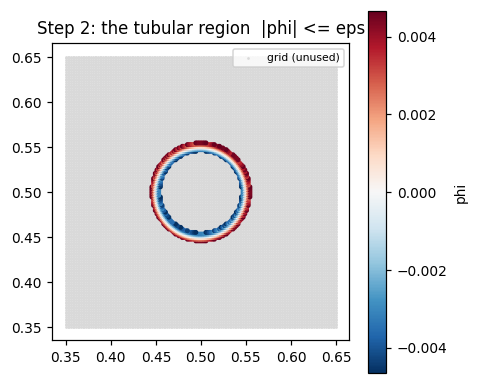

In [4]:
GRID = (161, 161)

# --- transparent version -------------------------------------------------
(xmin, ymin), (xmax, ymax) = BOUNDS
xs = torch.linspace(xmin, xmax, GRID[1], dtype=torch.float64)
ys = torch.linspace(ymin, ymax, GRID[0], dtype=torch.float64)
gy, gx = torch.meshgrid(ys, xs, indexing="ij")
grid_pts = torch.stack((gx, gy), dim=-1).reshape(-1, 2)

h = float((xmax - xmin) / (GRID[1] - 1))          # cell size
cell_area = h * h
eps_band = 2.5 * h                                 # the repo's default

pts = grid_pts.clone().requires_grad_(True)
phi_vals = phi(pts)
grad_phi = torch.autograd.grad(phi_vals, pts, torch.ones_like(phi_vals),
                               create_graph=True)[0]

in_band = (phi_vals[:, 0].abs() <= eps_band)
print("grid %dx%d, h = %.5f m, band half-width eps = %.5f m" % (GRID[0], GRID[1], h, eps_band))
print("grid points %d  ->  band points %d  (%.1f%%)" %
      (grid_pts.shape[0], int(in_band.sum()), 100*float(in_band.float().mean())))

fig, ax = plt.subplots(figsize=(4.4, 3.8))
bp = grid_pts[in_band].numpy()
ax.scatter(grid_pts[~in_band][:, 0], grid_pts[~in_band][:, 1], s=0.6, c="0.85", label="grid (unused)")
sc = ax.scatter(bp[:, 0], bp[:, 1], s=5, c=phi_vals[in_band, 0].detach().numpy(), cmap="RdBu_r")
plt.colorbar(sc, ax=ax, label="phi")
ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=7)
ax.set_title("Step 2: the tubular region  |phi| <= eps")
plt.tight_layout(); plt.show()

## Step 3 — boundary points, normals, weights

From the band, three quantities:

| quantity | formula | meaning |
|---|---|---|
| normal   | `n = grad phi / \|grad phi\|` | unit normal, defined everywhere |
| point    | `p = y - (phi/\|grad phi\|) n` | one Newton step onto `phi = 0` |
| weight   | `w = delta_eps(phi) * \|grad phi\| * h^2` | smeared delta collapses the ribbon onto the curve |

**The diagnostic that matters:** `sum(w)` should equal the perimeter `2*pi*R`.
One number tells you instantly whether the quadrature is sane.

The repo also carries a `strict` weight with the closest-point Jacobian
`J = 1 - tau*kappa` folded in. It is *off by default* — `use_strict_quadrature=False`.

In [5]:
def cosine_delta(v, half_width):
    '''Regularized delta with compact support |v| <= half_width.'''
    out = torch.zeros_like(v)
    m = v.abs() <= half_width
    out[m] = 0.5 * (1.0 + torch.cos(np.pi * v[m] / half_width)) / half_width
    return out

gnorm  = torch.linalg.norm(grad_phi, dim=1, keepdim=True).clamp_min(1e-8)
normal = grad_phi / gnorm
point  = pts - (phi_vals / gnorm) * normal
weight = cosine_delta(phi_vals, eps_band) * gnorm * cell_area

b_pts   = point[in_band].detach()
b_nrm   = normal[in_band].detach()
b_wgt   = weight[in_band].detach()

exact_perimeter = 2 * np.pi * RADIUS
print("sum(w)      = %.8f" % float(b_wgt.sum()))
print("2*pi*R      = %.8f" % exact_perimeter)
print("rel. error  = %.2e" % (abs(float(b_wgt.sum()) - exact_perimeter) / exact_perimeter))

# --- check against the repo ---------------------------------------------
band = build_implicit_boundary_band(phi, BOUNDS, grid_shape=GRID, dtype=torch.float64)
assert band.num_samples == int(in_band.sum())
assert torch.allclose(band.projected_points, b_pts)
assert torch.allclose(band.normals, b_nrm)
assert torch.allclose(band.quadrature_weights, b_wgt)
print("\nmatches build_implicit_boundary_band() exactly")
print("strict weights (with Jacobian J = 1 - tau*kappa): sum = %.8f  rel.err = %.2e"
      % (float(band.strict_quadrature_weights.sum()),
         abs(float(band.strict_quadrature_weights.sum()) - exact_perimeter) / exact_perimeter))

sum(w)      = 0.31412766
2*pi*R      = 0.31415927
rel. error  = 1.01e-04

matches build_implicit_boundary_band() exactly
strict weights (with Jacobian J = 1 - tau*kappa): sum = 0.31413755  rel.err = 6.91e-05


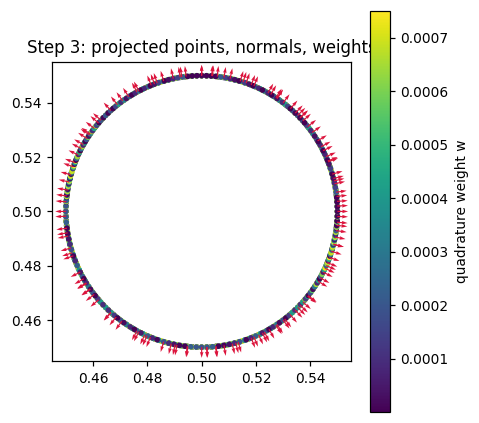

Note every band point projects onto the curve, so many points stack up at
almost the same location -- that is what compression fixes next.


In [6]:
fig, ax = plt.subplots(figsize=(4.4, 4.0))
sc = ax.scatter(b_pts[:, 0], b_pts[:, 1], s=7, c=b_wgt[:, 0], cmap="viridis")
q = slice(None, None, 6)
ax.quiver(b_pts[q, 0], b_pts[q, 1], b_nrm[q, 0], b_nrm[q, 1],
          color="crimson", scale=28, width=0.004)
plt.colorbar(sc, ax=ax, label="quadrature weight w")
ax.set_aspect("equal")
ax.set_title("Step 3: projected points, normals, weights")
plt.tight_layout(); plt.show()

print("Note every band point projects onto the curve, so many points stack up at")
print("almost the same location -- that is what compression fixes next.")

### Compression (optional, forward-only)

`compress_implicit_boundary_band` bins nearby projected points and sums their
weights. Note it uses `round` / `unique` / bin-merge — **a non-smooth chain**. The
repo's own design note (`docs/ibim_shape_derivative.md`, §10) flags this: fine for
the forward solve, but the backward pass must treat it as a frozen resampling
step rather than a differentiable map.

In [7]:
samples = compress_implicit_boundary_band(band)
print("band       N = %4d" % band.num_samples)
print("compressed N = %4d   (merge_distance = %.5f m)" % (samples.num_samples, samples.merge_distance))
print("sum(w) preserved: %.8f  vs  %.8f" %
      (float(samples.quadrature_weights.sum()), float(band.quadrature_weights.sum())))

band       N =  856
compressed N =  168   (merge_distance = 0.00234 m)
sum(w) preserved: 0.31412766  vs  0.31412766


## Step 4 — the Müller BIE

Four boundary operators, at *two* wavenumbers (exterior and interior):

- `V`  single layer
- `K`  double layer
- `K'` adjoint double layer
- `W`  hypersingular

### 4a. How the repo dodges the singularity

Layer potentials blow up as the evaluation point approaches the surface. A
mesh-based code handles this with special singular quadrature. IBIM can't — its
points are scattered, with no curve parameterization to integrate along.

So it uses a trick: evaluate the potential at `p ± d·n`, a small distance either
side, and **average**. The averaging kills the jump and leaves the principal
value. `d` is a free parameter — remember that, it comes back in the validation.

In [8]:
p_np = samples.points.numpy()
n_np = samples.normals.numpy()
w_np = samples.quadrature_weights.numpy().ravel()

def layer_potentials(targets, k):
    '''Single- and double-layer potentials at `targets` from the boundary samples.'''
    D = targets[:, None, :] - p_np[None, :, :]
    r = np.linalg.norm(D, axis=2)
    V = 0.25j * hankel1(0, k * r) * w_np[None, :]
    K = 0.25j * k * hankel1(1, k * r) * (np.einsum("mnd,nd->mn", D, n_np) / r) * w_np[None, :]
    return V, K

OFFSET = 2.0 * samples.merge_distance      # justified in the validation section

V_out, K_out = layer_potentials(p_np + OFFSET * n_np, K_EXT)
V_in,  K_in  = layer_potentials(p_np - OFFSET * n_np, K_EXT)
V_mine, K_mine = 0.5 * (V_out + V_in), 0.5 * (K_out + K_in)

fam = build_implicit_boundary_operator_family(samples, np.array([K_EXT]), offset_distance=OFFSET)
V_repo = np.asarray(fam.single_layer_matrix[0])
K_repo = np.asarray(fam.double_layer_matrix[0])
print("V matches repo: max rel diff = %.2e" % (np.abs(V_mine-V_repo).max()/np.abs(V_repo).max()))
print("K matches repo: max rel diff = %.2e" % (np.abs(K_mine-K_repo).max()/np.abs(K_repo).max()))
print("\n(K' and W follow the same pattern, but the repo builds them by one-sided")
print(" finite differences of the potential along the normal -- see")
print(" implicit_*_normal_derivative_trace_from_band, which samples at 1d, 2d, 3d.)")

V matches repo: max rel diff = 0.00e+00
K matches repo: max rel diff = 0.00e+00

(K' and W follow the same pattern, but the repo builds them by one-sided
 finite differences of the potential along the normal -- see
 implicit_*_normal_derivative_trace_from_band, which samples at 1d, 2d, 3d.)


### 4b. The cancellation that makes Müller well-conditioned — and whether it happens here

The point of Müller's formulation for the transmission problem is that the
*hypersingular* parts of the exterior and interior operators have the **same**
leading singularity as `r -> 0`, independent of the wavenumber. So they cancel —
leaving a weakly singular, second-kind, well-conditioned system.

Cancellation of a `k`-independent singularity happens in the **difference**
`W_ext - W_int`, not the sum. `build_ibim_tmz_frequency_system`
(`ibim_tmz_system.py:111-116`) uses the **sum**. Let's just measure it:

        ||M_e||     ||M_e + M_i||/||M_e||   ||M_e - M_i||/||M_e||
                       (what repo uses)        (Müller combo)
  V    6.869e-02         2.110                   0.4587
  K    9.857e-01         1.812                   0.5111
  K'   1.012e+00         1.802                   0.5105
  W    3.140e+02         2.000                   0.0455


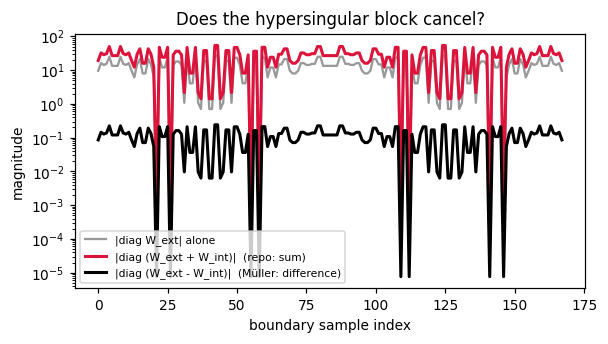


The hypersingular difference cancels 95% of the norm; the sum doubles it.
Note also ||W|| = 3.1e+02 vs ||V|| = 6.9e-02 -- the blocks differ in scale by ~5e+03,
which is what wrecks the conditioning of the assembled system below.


In [9]:
fam_e = build_implicit_boundary_operator_family(samples, np.array([K_EXT]), offset_distance=OFFSET)
fam_i = build_implicit_boundary_operator_family(samples, np.array([K_INT]), offset_distance=OFFSET)

blocks = [("V ", fam_e.single_layer_matrix,         fam_i.single_layer_matrix),
          ("K ", fam_e.double_layer_matrix,         fam_i.double_layer_matrix),
          ("K'", fam_e.adjoint_double_layer_matrix, fam_i.adjoint_double_layer_matrix),
          ("W ", fam_e.hypersingular_matrix,        fam_i.hypersingular_matrix)]

print("        ||M_e||     ||M_e + M_i||/||M_e||   ||M_e - M_i||/||M_e||")
print("                       (what repo uses)        (Müller combo)")
for nm, Me_, Mi_ in blocks:
    Me, Mi = np.asarray(Me_[0]), np.asarray(Mi_[0])
    ne = np.linalg.norm(Me)
    print("  %s   %9.3e        %6.3f                  %7.4f"
          % (nm, ne, np.linalg.norm(Me+Mi)/ne, np.linalg.norm(Me-Mi)/ne))

W_e = np.asarray(fam_e.hypersingular_matrix[0])
W_i = np.asarray(fam_i.hypersingular_matrix[0])

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.semilogy(np.abs(np.diag(W_e)), color="0.6", label="|diag W_ext| alone")
ax.semilogy(np.abs(np.diag(W_e + W_i)), lw=2, color="crimson", label="|diag (W_ext + W_int)|  (repo: sum)")
ax.semilogy(np.abs(np.diag(W_e - W_i)), lw=2, color="k", label="|diag (W_ext - W_int)|  (Müller: difference)")
ax.set_xlabel("boundary sample index"); ax.set_ylabel("magnitude")
ax.set_title("Does the hypersingular block cancel?"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

V_e_ = np.asarray(fam_e.single_layer_matrix[0])
cancel = np.linalg.norm(W_e - W_i) / np.linalg.norm(W_e)
print("\nThe hypersingular difference cancels %.0f%% of the norm; the sum doubles it." % (100*(1-cancel)))
print("Note also ||W|| = %.1e vs ||V|| = %.1e -- the blocks differ in scale by ~%.0e,"
      % (np.linalg.norm(W_e), np.linalg.norm(V_e_), np.linalg.norm(W_e)/np.linalg.norm(V_e_)))
print("which is what wrecks the conditioning of the assembled system below.")

### 4c. Assemble and solve

The block system, exactly as `build_ibim_tmz_frequency_system` builds it:

```
A = [ -(K_ext + K_int)     V_ext + V_int  ]
    [   W_ext + W_int      K'_ext + K'_int]
```

with unknowns `q = [u_D ; u_N]` (Dirichlet and Neumann traces) and right-hand
side `b = [b_D ; b_N]`, the incident field's traces.

The repo then solves `A^2 q = A b` rather than `A q = b`. Both give the same `q`
when `A` is invertible. Let's check what squaring actually costs:

In [10]:
system = build_ibim_tmz_frequency_system(
    samples, OMEGA, exterior=SAND, interior=PLASTIC,
    eps0=cfg.EPS0, mu0=cfg.MU0, offset_distance=OFFSET)

A  = np.asarray(system.system_matrix[0])
A2 = np.asarray(system.system_matrix_squared[0])
print("A shape %s  (2N x 2N with N = %d)" % (A.shape, system.num_boundary_samples))
print("cond(A)   = %.3e   <- already very high for N = %d" % (np.linalg.cond(A), system.num_boundary_samples))
print("cond(A^2) = %.3e   <- past double precision (~1e16)" % np.linalg.cond(A2))
print("\nSquaring roughly squares the condition number, so it makes conditioning")
print("WORSE, not better -- and here it pushes past what float64 can represent.")

src_pt = np.array([[CENTER[0] - 0.30, CENTER[1]]])
bD, bN = ibim_incident_trace_on_boundary(samples, src_pt, OMEGA, 1.0,
                                         exterior=SAND, eps0=cfg.EPS0, mu0=cfg.MU0)
b = np.concatenate((bD, bN), axis=1).T

q_direct  = np.linalg.solve(A, b)
q_squared = np.linalg.solve(A2, A @ b)          # what the repo actually solves
rel = np.linalg.norm(q_direct-q_squared)/np.linalg.norm(q_direct)
print("\n||q_direct - q_squared|| / ||q_direct|| = %.2e" % rel)
print("\nIn exact arithmetic these are identical. They differ by ~%.1f%% here, which"
      % (100*rel))
print("is the conditioning of A^2 showing up as lost precision in the traces.")

A shape (336, 336)  (2N x 2N with N = 168)
cond(A)   = 3.727e+12   <- already very high for N = 168
cond(A^2) = 2.277e+18   <- past double precision (~1e16)

Squaring roughly squares the condition number, so it makes conditioning
WORSE, not better -- and here it pushes past what float64 can represent.

||q_direct - q_squared|| / ||q_direct|| = 2.20e-02

In exact arithmetic these are identical. They differ by ~2.2% here, which
is the conditioning of A^2 showing up as lost precision in the traces.


## Step 5 — receiver fields

With the traces known, the scattered field anywhere in the exterior is

```
u_scattered(x) = (D u_D)(x) - (S u_N)(x)
u_total(x)     = u_incident(x) + u_scattered(x)
```

Here is the whole pipeline behind your intended signature:

In [11]:
def muller_bie(sdf, bounds, eps_in, eps_out, frequency, source_points, receiver_points,
               grid_shape=(161, 161), offset_scale=2.0, strength=1.0):
    '''phi -> band -> boundary samples -> Muller BIE -> receiver fields.'''
    band = build_implicit_boundary_band(sdf, bounds, grid_shape=grid_shape, dtype=torch.float64)
    boundary = compress_implicit_boundary_band(band)
    return solve_ibim_tmz_total_field_batch(
        boundary, source_points, receiver_points, 2*np.pi*frequency, strength,
        exterior=Material(epsr=eps_out), interior=Material(epsr=eps_in),
        eps0=cfg.EPS0, mu0=cfg.MU0,
        offset_distance=offset_scale * boundary.merge_distance)

# a ring of bistatic Tx/Rx pairs around the target
ang = np.linspace(0, 2*np.pi, 24, endpoint=False)
RSTAND = 0.30
tx = np.column_stack((CENTER[0] + RSTAND*np.cos(ang), CENTER[1] + RSTAND*np.sin(ang)))
rx = np.column_stack((CENTER[0] + RSTAND*np.cos(ang + cfg.TX_RX_OFFSET/RSTAND),
                      CENTER[1] + RSTAND*np.sin(ang + cfg.TX_RX_OFFSET/RSTAND)))

result = muller_bie(phi, BOUNDS, cfg.PLASTIC_EPSR, cfg.SAND_EPSR, FREQ, tx, rx)
print("|incident|  mean %.5f" % np.abs(result.incident_receiver).mean())
print("|scattered| mean %.5f  (%.1f%% of incident)" %
      (np.abs(result.scattered_receiver).mean(),
       100*np.abs(result.scattered_receiver).mean()/np.abs(result.incident_receiver).mean()))

|incident|  mean 0.15789
|scattered| mean 0.00504  (3.2% of incident)


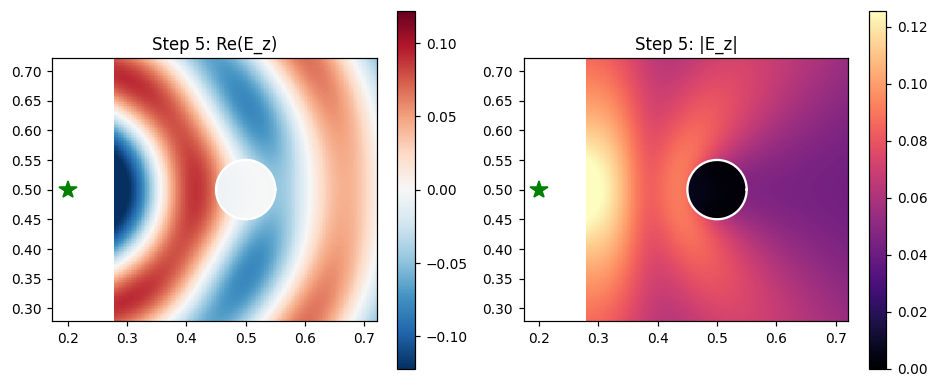

Note the field inside the cylinder: shorter wavelength (higher index) and
the shadow/forward-scattering lobe behind it.


In [12]:
# Field map for a single transmitter: solve once, then evaluate the
# representation formula on a grid of points.
one_tx = np.array([[CENTER[0] - 0.30, CENTER[1]]])
one_rx = np.array([[CENTER[0] - 0.30, CENTER[1] + cfg.TX_RX_OFFSET]])
r1 = solve_ibim_tmz_total_field_batch(samples, one_tx, one_rx, OMEGA, 1.0,
        exterior=SAND, interior=PLASTIC, eps0=cfg.EPS0, mu0=cfg.MU0, offset_distance=OFFSET)

uD, uN = r1.dirichlet_total[0], r1.neumann_total[0]
gm = np.linspace(CENTER[0]-0.22, CENTER[0]+0.22, 161)
MX, MY = np.meshgrid(gm, gm)
P = np.column_stack((MX.ravel(), MY.ravel()))

S = implicit_single_layer_potential_from_band(P, samples, uN, K_EXT).potentials[0]
D = implicit_double_layer_potential_from_band(P, samples, uD, K_EXT).potentials[0]
u_inc = 0.25j * hankel1(0, K_EXT * np.linalg.norm(P - one_tx[0], axis=1))
u_tot = (u_inc + D - S).reshape(MX.shape)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6))
for a, f, t in zip(axes, [np.real(u_tot), np.abs(u_tot)], ["Re(E_z)", "|E_z|"]):
    lim = np.percentile(np.abs(f), 99)
    im = a.pcolormesh(MX, MY, f, cmap="RdBu_r" if "Re" in t else "magma",
                      vmin=-lim if "Re" in t else 0, vmax=lim, shading="auto")
    th = np.linspace(0, 2*np.pi, 200)
    a.plot(CENTER[0]+RADIUS*np.cos(th), CENTER[1]+RADIUS*np.sin(th), "w-", lw=1.5)
    a.plot(*one_tx[0], "g*", ms=12)
    a.set_aspect("equal"); a.set_title("Step 5: %s" % t)
    plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()
print("Note the field inside the cylinder: shorter wavelength (higher index) and")
print("the shadow/forward-scattering lobe behind it.")

---

# Validation — is any of this right?

Everything above shows the machinery *runs*. It does not show it is *correct*.
A penetrable circular cylinder has an exact solution, so let's build it and find out.

For a line source (which is what the repo uses — `0.25j*H0`), Graf's addition
theorem expands the incident field in cylindrical harmonics about the target:

```
(i/4) H0(k1 |r - r0|) = (i/4) sum_n H_n(k1 rho0) J_n(k1 rho) e^{i n (theta - theta0)}
```

Matching `u` and `du/dn` at `rho = a` mode-by-mode gives the scattering coefficients.

In [13]:
def mie_scattered(receivers, sources, k1, k2, a, center, strength=1.0, nmax=60):
    '''Exact scattered E_z from a penetrable circle, line source. Paired rx/src.'''
    out = np.zeros(len(receivers), dtype=complex)
    n = np.arange(-nmax, nmax + 1)
    num = k2*jvp(n, k2*a)*jv(n, k1*a) - k1*jvp(n, k1*a)*jv(n, k2*a)
    den = k1*h1vp(n, k1*a)*jv(n, k2*a) - k2*jvp(n, k2*a)*hankel1(n, k1*a)
    for i, (r, s) in enumerate(zip(np.atleast_2d(receivers), np.atleast_2d(sources))):
        dr, ds = r - np.asarray(center), s - np.asarray(center)
        rho_r, th_r = np.hypot(*dr), np.arctan2(dr[1], dr[0])
        rho_0, th_0 = np.hypot(*ds), np.arctan2(ds[1], ds[0])
        a_n = hankel1(n, k1*rho_0) * num/den
        out[i] = strength * 0.25j * np.sum(a_n * hankel1(n, k1*rho_r) * np.exp(1j*n*(th_r-th_0)))
    return out

# --- self-tests on the exact solution before we trust it -----------------
k1r, k2r = K_EXT.real, K_INT.real
n = np.arange(-60, 61)

# (1) no contrast -> no scattering
num0 = k1r*jvp(n,k1r*RADIUS)*jv(n,k1r*RADIUS) - k1r*jvp(n,k1r*RADIUS)*jv(n,k1r*RADIUS)
print("T1  zero contrast, max|numerator| = %.3e   (want 0)" % np.abs(num0).max())

# (2) the coefficients really do satisfy the transmission conditions
num = k2r*jvp(n,k2r*RADIUS)*jv(n,k1r*RADIUS) - k1r*jvp(n,k1r*RADIUS)*jv(n,k2r*RADIUS)
den = k1r*h1vp(n,k1r*RADIUS)*jv(n,k2r*RADIUS) - k2r*jvp(n,k2r*RADIUS)*hankel1(n,k1r*RADIUS)
a_n = hankel1(n, k1r*0.30) * num/den
b_n = (hankel1(n,k1r*0.30)*jv(n,k1r*RADIUS) + a_n*hankel1(n,k1r*RADIUS)) / jv(n,k2r*RADIUS)
th = 0.7
u_out  = np.sum((hankel1(n,k1r*0.30)*jv(n,k1r*RADIUS) + a_n*hankel1(n,k1r*RADIUS))*np.exp(1j*n*th))
u_in   = np.sum(b_n*jv(n,k2r*RADIUS)*np.exp(1j*n*th))
du_out = np.sum(k1r*(hankel1(n,k1r*0.30)*jvp(n,k1r*RADIUS) + a_n*h1vp(n,k1r*RADIUS))*np.exp(1j*n*th))
du_in  = np.sum(k2r*b_n*jvp(n,k2r*RADIUS)*np.exp(1j*n*th))
print("T2  Dirichlet jump %.2e, Neumann jump %.2e  (field magnitude %.2e)"
      % (abs(u_out-u_in), abs(du_out-du_in), abs(u_out)))
print("\nThe exact solution satisfies the transmission conditions to machine")
print("precision, so it is trustworthy as a reference.")

T1  zero contrast, max|numerator| = 0.000e+00   (want 0)
T2  Dirichlet jump 5.55e-17, Neumann jump 4.44e-16  (field magnitude 3.45e-01)

The exact solution satisfies the transmission conditions to machine
precision, so it is trustworthy as a reference.


### The comparison

Symmetry gives us a free extra check: for a circle with a *fixed* Tx–Rx angular
offset, rotating the pair around the target must leave `|u_scattered|` unchanged.
Any variation across the ring is pure discretization error.

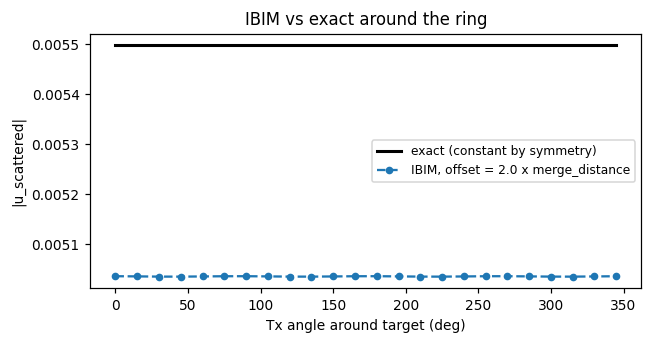

relative L2 error = 0.0915
residual ripple is the Cartesian grid's 4-fold symmetry leaking into a
problem that should be rotationally symmetric.


In [14]:
exact = mie_scattered(rx, tx, K_EXT.real, K_INT.real, RADIUS, CENTER)
ibim  = result.scattered_receiver

fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(np.degrees(ang), np.abs(exact), "k-", lw=2, label="exact (constant by symmetry)")
ax.plot(np.degrees(ang), np.abs(ibim), "o--", ms=4, label="IBIM, offset = 2.0 x merge_distance")
ax.set_xlabel("Tx angle around target (deg)"); ax.set_ylabel("|u_scattered|")
ax.legend(fontsize=8); ax.set_title("IBIM vs exact around the ring")
plt.tight_layout(); plt.show()

print("relative L2 error = %.4f" % (np.linalg.norm(ibim-exact)/np.linalg.norm(exact)))
print("residual ripple is the Cartesian grid's 4-fold symmetry leaking into a")
print("problem that should be rotationally symmetric.")

### Finding 1 — the default offset distance is in a divergent regime

`OFFSET` was set to `2.0 * merge_distance` earlier without justification. Here is
the justification — and the reason it matters.

The offset `d` is squeezed between two failure modes: too small and the discrete
quadrature cannot resolve the near-singular kernel; too large and the `±d` average
stops approximating the on-surface trace. Sweeping it:

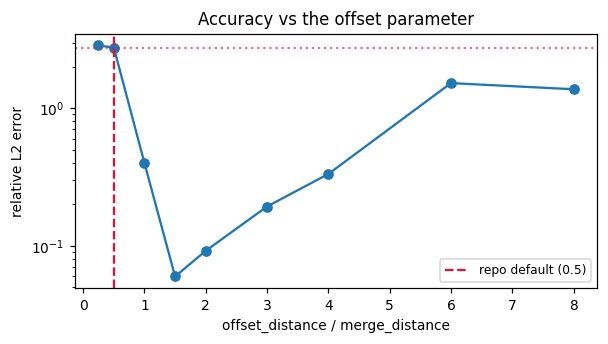

  offset = 0.25 x md   rel.err =  2.8642 
  offset = 0.50 x md   rel.err =  2.7652   <-- repo default
  offset = 1.00 x md   rel.err =  0.3985 
  offset = 1.50 x md   rel.err =  0.0595 
  offset = 2.00 x md   rel.err =  0.0915 
  offset = 3.00 x md   rel.err =  0.1923 
  offset = 4.00 x md   rel.err =  0.3317 
  offset = 6.00 x md   rel.err =  1.5225 
  offset = 8.00 x md   rel.err =  1.3735 

repo default (_default_trace_offset_distance = 0.5*merge_distance): 2.7652


In [15]:
ratios = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0]
errs = []
for rr in ratios:
    r_ = solve_ibim_tmz_total_field_batch(samples, tx, rx, OMEGA, 1.0,
            exterior=SAND, interior=PLASTIC, eps0=cfg.EPS0, mu0=cfg.MU0,
            offset_distance=rr*samples.merge_distance)
    errs.append(np.linalg.norm(r_.scattered_receiver-exact)/np.linalg.norm(exact))

default_err = np.linalg.norm(
    solve_ibim_tmz_total_field_batch(samples, tx, rx, OMEGA, 1.0, exterior=SAND,
        interior=PLASTIC, eps0=cfg.EPS0, mu0=cfg.MU0).scattered_receiver - exact
) / np.linalg.norm(exact)

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.semilogy(ratios, errs, "o-")
ax.axvline(0.5, color="crimson", ls="--", label="repo default (0.5)")
ax.axhline(default_err, color="crimson", ls=":", alpha=0.6)
ax.set_xlabel("offset_distance / merge_distance"); ax.set_ylabel("relative L2 error")
ax.set_title("Accuracy vs the offset parameter"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for rr, e in zip(ratios, errs):
    print("  offset = %4.2f x md   rel.err = %7.4f %s" %
          (rr, e, "  <-- repo default" if rr == 0.5 else ""))
print("\nrepo default (_default_trace_offset_distance = 0.5*merge_distance): %.4f" % default_err)

The default sits on the wrong side of a cliff. `_default_trace_offset_distance`
in `ibim_tmz_forward.py:764` returns `0.5 * merge_distance` for compressed
samples, landing in the regime where the error is order-1 — and, crucially,
**does not improve when you refine the grid**:

In [16]:
print(" grid    N     default offset        offset = 2.0 x md")
print("                err    |ibim|/|exact|    err    |ibim|/|exact|")
for ng in (121, 161, 241, 321):
    bd = build_implicit_boundary_band(phi, BOUNDS, grid_shape=(ng, ng), dtype=torch.float64)
    sm = compress_implicit_boundary_band(bd)
    row = [ng, sm.num_samples]
    for off in (None, 2.0*sm.merge_distance):
        rr_ = solve_ibim_tmz_total_field_batch(sm, tx, rx, OMEGA, 1.0, exterior=SAND,
                interior=PLASTIC, eps0=cfg.EPS0, mu0=cfg.MU0, offset_distance=off)
        sc = rr_.scattered_receiver
        row += [np.linalg.norm(sc-exact)/np.linalg.norm(exact),
                np.abs(sc).mean()/np.abs(exact).mean()]
    print("%5d %4d   %7.3f  %7.3f      %7.4f  %7.4f" % tuple(row))
print("\nDefault: error frozen near 2.8 and magnitude pinned at ~2.03x, refinement")
print("does not help -- a systematic error, not a resolution problem.")
print("At 2.0 x merge_distance the error falls steadily with resolution.")

 grid    N     default offset        offset = 2.0 x md
                err    |ibim|/|exact|    err    |ibim|/|exact|


  121  128     2.741    2.040       0.1546   0.8578


  161  168     2.765    2.038       0.0915   0.9161


  241  240     2.816    2.034       0.0454   0.9590


  321  336     2.817    2.031       0.0284   0.9748

Default: error frozen near 2.8 and magnitude pinned at ~2.03x, refinement
does not help -- a systematic error, not a resolution problem.
At 2.0 x merge_distance the error falls steadily with resolution.


### Finding 2 — compression is non-monotonic in grid resolution

Watch `N` in the table above, and push the grid further. `merge_distance` shrinks
with `h`, but the retry heuristic in `compress_implicit_boundary_band`
(`target_min_samples = max(16, 4*sqrt(N_band))`, halving the merge scale up to 6
times) can *reduce* the sample count as the grid gets finer — which stalls or
reverses convergence.

In [17]:
print(" grid   band N   compressed N   merge_dist    rel.err (offset=2md)")
for ng in (121, 161, 241, 321, 401, 481):
    bd = build_implicit_boundary_band(phi, BOUNDS, grid_shape=(ng, ng), dtype=torch.float64)
    sm = compress_implicit_boundary_band(bd)
    rr_ = solve_ibim_tmz_total_field_batch(sm, tx, rx, OMEGA, 1.0, exterior=SAND,
            interior=PLASTIC, eps0=cfg.EPS0, mu0=cfg.MU0,
            offset_distance=2.0*sm.merge_distance)
    print("%5d   %5d      %5d       %.6f      %7.4f" %
          (ng, bd.num_samples, sm.num_samples, sm.merge_distance,
           np.linalg.norm(rr_.scattered_receiver-exact)/np.linalg.norm(exact)))
print("\nN should grow monotonically with grid resolution. It does not.")

 grid   band N   compressed N   merge_dist    rel.err (offset=2md)
  121     624        128       0.003125       0.1546


  161     856        168       0.002344       0.0915


  241    1260        240       0.001563       0.0454


  321    1668        336       0.001172       0.0284


  401    2088        216       0.001875       0.0618


  481    2508        248       0.001563       0.0453

N should grow monotonically with grid resolution. It does not.


---

## What this notebook established

**The pipeline, stage by stage.** Every step was written out plainly and then
asserted equal to the repo's own implementation — the geometry (`Step 3`) and the
operators (`Step 4a`) match bit-for-bit.

**The geometry is excellent.** `sum(w)` reproduces the perimeter to ~1e-5
relative, and the strict (Jacobian-corrected) weights do better still.

**The solver does converge to the exact solution** once the offset is set sanely —
0.155 -> 0.092 -> 0.045 -> 0.028 as the grid refines. The formulation is sound.
But three things are costing accuracy, none of them visible without an exact
reference to compare against:

1. **`_default_trace_offset_distance` is in a divergent regime.**
   (`gpr_bem/ibim_tmz_forward.py:764`, the `ImplicitBoundarySamples2D` branch:
   `0.5 * merge_distance`.) It produces a systematic ~2x error in the scattered
   field that does **not** decrease under grid refinement. Roughly `1.5-2.0 x
   merge_distance` sits in the accuracy valley and converges. Every inverse result
   rests on this forward solve, so this is the one to fix first.

2. **The operator combination is not the Müller combination.**
   `ibim_tmz_system.py:111-116` sums exterior and interior blocks. The
   `k`-independent hypersingular singularity cancels in the **difference**
   (`||W_e - W_i|| / ||W_e||` is 0.05 at this resolution, 0.025 at finer — i.e.
   95-98% cancellation) but the sum doubles it (`2.00`). The consequence is
   `||W|| / ||V|| ~ 5e3` and `cond(A) ~ 1e10-1e12`,
   where a properly cancelled second-kind system would be far better behaved.
   This is a conditioning problem, not a correctness one — the system still
   converges — but it is why the `A^2 q = A b` solve loses ~2% (`cond(A^2) ~ 1e18`
   exceeds float64). Worth checking against the formulation you intended.

3. **`compress_implicit_boundary_band` is non-monotonic in resolution.** The
   sample count can fall as the grid is refined, stalling convergence.

### Natural next steps

- Re-run with `SirenSDF2D` in place of the analytic circle (drop-in, same signature)
- Multi-frequency -> B-scan via `solve_ibim_tmz_frequency_response` + `bscan_from_frequency_response`
- The adjoint: `mu^H (b_dot - A_dot q) + psi^H (C_dot q)`, which is what the whole
  differentiable-geometry design exists to support